In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [32]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# Baseline period Monthly Climatology
BASELINE_PERIOD = slice("1995-01-01", "2014-12-31")
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260910",
                                     baseline_period=BASELINE_PERIOD, 
                                     rate=False, 
                                     months = FC_MONTHS,
                                     hotonly = "hotonly")

# Define Forecast
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/v20260909_effects_with_betas.zarr"

In [24]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)

In [ ]:
analysis_utils.make_csv(effect, config, group_level="ADM1")

source coverage: 6 unmatched source units (first 6: [['BRA.8.823.1961'], ['IDN.14.203'], ['IND.12.129.431'], ['IND.12.129.432'], ['VNM.4.37.365.6048'], ['ZAF.9.313']]); recorded in the manifest and skipped


In [12]:
impact = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=BASELINE_PERIOD, hotonly = "net", rate = False, age_weight = True)

In [13]:
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = ['number', 'sample']), _polygons)

In [15]:
_polygons_impact

,region,gadmid,color,ISO,AREA,PERIMETER,geometry,month,year,age_weighted_impact
0,CAN.1.2.28,28115,1,CAN,0.001442,0.184641,"POLYGON ((-8802835.684 5666589.015, -8798943.7...",1,2026,-0.163274
1,CAN.1.2.28,28115,1,CAN,0.001442,0.184641,"POLYGON ((-8802835.684 5666589.015, -8798943.7...",2,2026,-0.258906
2,CAN.1.2.28,28115,1,CAN,0.001442,0.184641,"POLYGON ((-8802835.684 5666589.015, -8798943.7...",3,2026,-0.955861
3,CAN.1.2.28,28115,1,CAN,0.001442,0.184641,"POLYGON ((-8802835.684 5666589.015, -8798943.7...",9,2026,-0.146887
4,CAN.1.2.28,28115,1,CAN,0.001442,0.184641,"POLYGON ((-8802835.684 5666589.015, -8798943.7...",10,2026,-0.364030
...,...,...,...,...,...,...,...,...,...,...
170641,BWA.4.13,6912,24378,BWA,0.692807,3.840323,"POLYGON ((2485439.733 -2540098.208, 2483663.32...",3,2026,-0.456942
170642,BWA.4.13,6912,24378,BWA,0.692807,3.840323,"POLYGON ((2485439.733 -2540098.208, 2483663.32...",9,2026,1.928849
170643,BWA.4.13,6912,24378,BWA,0.692807,3.840323,"POLYGON ((2485439.733 -2540098.208, 2483663.32...",10,2026,0.602969
170644,BWA.4.13,6912,24378,BWA,0.692807,3.840323,"POLYGON ((2485439.733 -2540098.208, 2483663.32...",11,2026,-0.115747


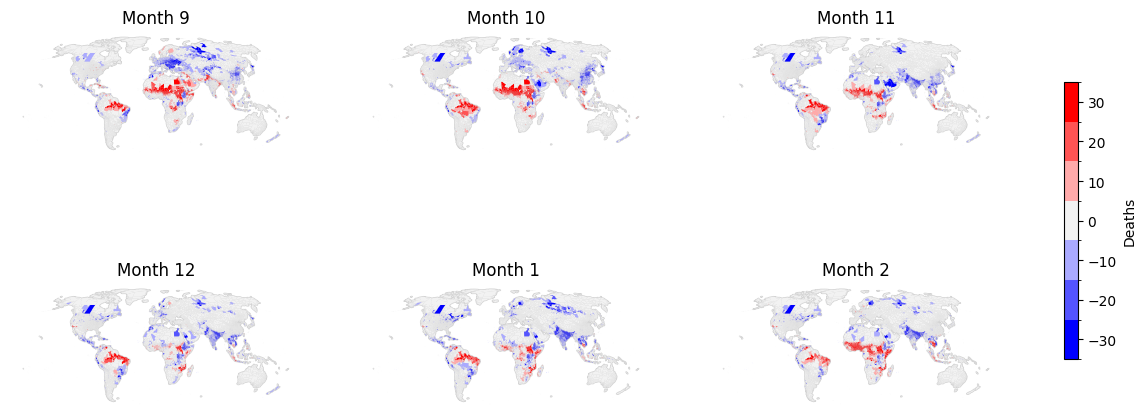

In [14]:
# Plot Impact on a Monthly Basis
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col='age_weighted_impact',
    cm = 'bwr',
    sup_title="",
    cbar_label= impact.units,
    month_order= FC_MONTHS
)
